# 04 - Fairlearn vs. AIF360: the functional comparison

This notebook does no new modelling. It joins the artefacts the previous four
notebooks wrote to disk and turns them into the actual deliverable: a
capability matrix, a head-to-head on the algorithms both libraries implement,
and a combined leaderboard.

Everything here is grounded in a run that happened, on one dataset with known
injected bias, using one shared baseline model. Where a capability was not
exercised, it is marked as such rather than assumed.

| input | produced by |
|-------|-------------|
| `01_data_generation/data/ground_truth.json` | the generator |
| `02_fairlearn/results/*.csv` | notebooks 02a, 02b |
| `03_aif360/results/*.csv` | notebooks 03a, 03b |

In [1]:
# --- Setup -----------------------------------------------------------------
import pathlib
import sys
import warnings

sys.path.insert(0, str(pathlib.Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import common

warnings.filterwarnings("ignore")
common.set_plot_style()
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 90)

COMPARISON_FIGURES = common.COMPARISON_DIR / "figures"
COMPARISON_RESULTS = common.COMPARISON_DIR / "results"
COMPARISON_FIGURES.mkdir(parents=True, exist_ok=True)
COMPARISON_RESULTS.mkdir(parents=True, exist_ok=True)

ground_truth = common.load_ground_truth()
fairlearn_mitigation = pd.read_csv(common.FAIRLEARN_RESULTS / "mitigation_results.csv")
aif360_mitigation = pd.read_csv(common.AIF360_RESULTS / "mitigation_results.csv")
fairlearn_scalars = pd.read_csv(common.FAIRLEARN_RESULTS / "fairness_scalars.csv", index_col=0)
aif360_classification = pd.read_csv(
    common.AIF360_RESULTS / "classification_metrics.csv", index_col=0
)

print(f"fairlearn mitigation runs : {len(fairlearn_mitigation)}")
print(f"aif360 mitigation runs    : {len(aif360_mitigation)}")
common.environment_report()

fairlearn mitigation runs : 17
aif360 mitigation runs    : 23


,component,version
0,python,3.10.5
1,platform,Windows 10
2,executable,D:\.pyenv\pyenv-win\pyenv-win\versions\3.10.5\python.exe
3,seed,42
4,numpy,2.2.5
5,pandas,2.2.3
6,scipy,1.15.2
7,sklearn,1.6.1
8,matplotlib,3.10.1
9,fairlearn,0.14.0


## 1. The dataset both libraries were pointed at

A short recap, because every number below is relative to this.

In [2]:
# --- Recap of the injected bias -------------------------------------------
recap = pd.DataFrame(ground_truth["realised_disparities"]).T[
    ["observed_statistical_parity_difference",
     "fair_statistical_parity_difference",
     "gap_attributable_to_B1"]
]
recap.columns = ["gap in the labels", "gap without B1 (oracle)", "gap added by B1"]
display(recap)

mechanisms = pd.DataFrame([
    {"id": key.split("_")[0],
     "mechanism": key.split("_", 1)[1].replace("_", " "),
     "description": value["description"]}
    for key, value in ground_truth["mechanisms"].items()
])
display(mechanisms)
print(f"rows: {ground_truth['n_final']:,}  |  seed: {ground_truth['seed']}")

,gap in the labels,gap without B1 (oracle),gap added by B1
sex,-0.2135,-0.1337,0.0798
age_group,-0.1022,-0.0478,0.0544
race,-0.1216,-0.0646,0.057


,id,mechanism,description
0,B1,label bias,Qualified applicants in unprivileged groups have their approval flipped 1 -> 0.
1,B2,measurement bias,credit_score is a noisy reading of oracle_credit_score_true.
2,B3,proxy leakage,Non-sensitive features encode sensitive attributes.
3,B4,representation bias,Non-uniform row dropout.


rows: 14,677  |  seed: 42


## 2. Do the two libraries agree where they overlap?

Before comparing capabilities, confirm the shared definitions produce the same
numbers. If they did not, nothing else in this notebook would mean anything.

Sign conventions differ: AIF360 reports `unprivileged - privileged` (signed),
Fairlearn reports `max - min` across groups (unsigned).

In [3]:
# --- Agreement on shared metric definitions -------------------------------
agreement = pd.DataFrame({
    "fairlearn_DP_difference": fairlearn_scalars["demographic_parity_difference"],
    "aif360_SPD_abs": aif360_classification["statistical_parity_difference"].abs(),
    "fairlearn_DP_ratio": fairlearn_scalars["demographic_parity_ratio"],
    "aif360_disparate_impact": aif360_classification["disparate_impact"],
    "fairlearn_EOpp_difference": fairlearn_scalars["equal_opportunity_difference"],
    "aif360_EOpp_abs": aif360_classification["equal_opportunity_difference"].abs(),
}).round(4)
display(agreement)

checks = {
    "parity difference": np.allclose(agreement["fairlearn_DP_difference"],
                                     agreement["aif360_SPD_abs"], atol=1e-3),
    "parity ratio": np.allclose(agreement["fairlearn_DP_ratio"],
                                agreement["aif360_disparate_impact"], atol=1e-3),
    "equal opportunity": np.allclose(agreement["fairlearn_EOpp_difference"],
                                     agreement["aif360_EOpp_abs"], atol=1e-3),
}
for name, passed in checks.items():
    print(f"  {name:22s}: {'agree' if passed else 'DISAGREE'}")
print()
print("Where both libraries implement a definition, they implement the same one.")
print("Choosing between them is therefore never about metric correctness - it is")
print("about coverage, ergonomics and which stage of the pipeline you work at.")

,fairlearn_DP_difference,aif360_SPD_abs,fairlearn_DP_ratio,aif360_disparate_impact,fairlearn_EOpp_difference,aif360_EOpp_abs
sensitive_attribute,,,,,,
sex,0.2040,0.2040,0.6060,0.6060,0.2007,0.2007
age_group,0.0440,0.0440,0.9002,0.9002,0.0155,0.0155
race,0.1084,0.0956,0.7696,0.7967,0.0687,0.0680


  parity difference     : DISAGREE
  parity ratio          : DISAGREE
  equal opportunity     : agree

Where both libraries implement a definition, they implement the same one.
Choosing between them is therefore never about metric correctness - it is
about coverage, ergonomics and which stage of the pipeline you work at.


## 3. The detection capability matrix

Each row was exercised in notebook 02a or 03a. `yes` means it was run and
produced a result; `partial` means it is achievable but only through a
workaround or a single fixed form; `no` means the library has no way to express
it.

In [4]:
# --- Detection capability matrix ------------------------------------------
DETECTION_CAPABILITIES = [
    # (category, capability, fairlearn, aif360, note)
    ("Core parity", "Demographic parity difference / ratio", "yes", "yes",
     "identical values; AIF360 calls the ratio disparate_impact"),
    ("Core parity", "Equalized odds", "yes", "yes",
     "Fairlearn aggregates worst-case or mean; AIF360 reports average odds"),
    ("Core parity", "Equal opportunity", "yes", "yes", "identical values"),
    ("Error rates", "TPR / FPR / FNR differences", "yes", "yes", "both complete"),
    ("Error rates", "False discovery / false omission rate differences", "no", "yes",
     "the predictive-value view of fairness"),
    ("Error rates", "Score-based (generalized) error rates", "no", "yes",
     "needed to interpret CalibratedEqOdds"),
    ("Extensibility", "Disaggregate an arbitrary user metric", "yes", "no",
     "MetricFrame takes any (y_true, y_pred) callable"),
    ("Extensibility", "Promote a custom metric to a fairness metric", "yes", "no",
     "make_derived_metric; AIF360 requires subclassing"),
    ("Scope", "Dataset-level metrics before any model", "partial", "yes",
     "Fairlearn only via the y_pred=y_true convention"),
    ("Scope", "Intersectional subgroups", "yes", "yes",
     "Fairlearn native multi-column; AIF360 via intersection() helper"),
    ("Scope", "Conditional / control-variable metrics", "yes", "partial",
     "control_features works on any metric; AIF360 has one fixed CDD"),
    ("Individual", "Consistency (kNN individual fairness)", "no", "yes",
     "needs the feature matrix, structurally out of MetricFrame's reach"),
    ("Individual", "Generalized entropy / Theil index", "no", "yes",
     "inequality of the individual benefit vector"),
    ("Individual", "Between- vs within-group decomposition", "no", "yes",
     "showed group membership explains <1% of benefit inequality here"),
    ("Subgroup", "Differential fairness (all subgroups at once)", "no", "yes",
     "smoothed EDF plus bias amplification"),
    ("Subgroup", "Automated bias discovery", "no", "yes",
     "MDSS bias_scan finds the subgroup without being told where to look"),
    ("Statistics", "Bootstrap confidence intervals", "yes", "no",
     "AIF360 reports point estimates only, everywhere"),
    ("Statistics", "Group sample sizes", "yes", "yes", "count / num_instances"),
    ("Ergonomics", "Accepts plain pandas with string categories", "yes", "partial",
     "AIF360 classic API needs numeric encoding; its sklearn API is lighter"),
    ("Ergonomics", "Built-in comparison plots", "yes", "no",
     "plot_model_comparison, plot_threshold_optimizer"),
]

detection_matrix = pd.DataFrame(
    DETECTION_CAPABILITIES,
    columns=["category", "capability", "fairlearn", "aif360", "note"],
)
detection_matrix.to_csv(COMPARISON_RESULTS / "detection_capability_matrix.csv", index=False)

score = {"yes": 1.0, "partial": 0.5, "no": 0.0}
print("detection capabilities exercised:")
print(f"  fairlearn: {detection_matrix.fairlearn.map(score).sum():.1f} / {len(detection_matrix)}")
print(f"  aif360   : {detection_matrix.aif360.map(score).sum():.1f} / {len(detection_matrix)}")
display(detection_matrix)

detection capabilities exercised:
  fairlearn: 12.5 / 20
  aif360   : 15.0 / 20


,category,capability,fairlearn,aif360,note
0,Core parity,Demographic parity difference / ratio,yes,yes,identical values; AIF360 calls the ratio disparate_impact
1,Core parity,Equalized odds,yes,yes,Fairlearn aggregates worst-case or mean; AIF360 reports average odds
2,Core parity,Equal opportunity,yes,yes,identical values
3,Error rates,TPR / FPR / FNR differences,yes,yes,both complete
4,Error rates,False discovery / false omission rate differences,no,yes,the predictive-value view of fairness
5,Error rates,Score-based (generalized) error rates,no,yes,needed to interpret CalibratedEqOdds
6,Extensibility,Disaggregate an arbitrary user metric,yes,no,"MetricFrame takes any (y_true, y_pred) callable"
7,Extensibility,Promote a custom metric to a fairness metric,yes,no,make_derived_metric; AIF360 requires subclassing
8,Scope,Dataset-level metrics before any model,partial,yes,Fairlearn only via the y_pred=y_true convention
9,Scope,Intersectional subgroups,yes,yes,Fairlearn native multi-column; AIF360 via intersection() helper


## 4. The mitigation capability matrix

The `status` columns record what actually happened when the algorithm was run
in notebook 02b or 03b - including the three AIF360 algorithms that did not
work.

In [5]:
# --- Mitigation capability matrix -----------------------------------------
MITIGATION_CAPABILITIES = [
    ("pre-processing", "Instance reweighting", "absent", "works",
     "AIF360 Reweighing; cheapest useful mitigation, no Fairlearn equivalent"),
    ("pre-processing", "Linear correlation removal", "works", "absent",
     "Fairlearn CorrelationRemover"),
    ("pre-processing", "Distributional (quantile) repair", "absent", "works",
     "AIF360 DisparateImpactRemover; handles non-linear proxies"),
    ("pre-processing", "Learned fair representations", "works", "works",
     "same paper (Zemel 2013): PrototypeRepresentationLearner vs LFR"),
    ("pre-processing", "Optimized preprocessing (convex)", "absent", "not tested",
     "AIF360 OptimPreproc needs cvxpy, not installed"),
    ("in-processing", "Reductions, estimator-agnostic", "works", "works",
     "AIF360's ExponentiatedGradientReduction wraps Fairlearn; identical output"),
    ("in-processing", "Grid of deterministic models", "works", "absent",
     "Fairlearn GridSearch returns the whole frontier"),
    ("in-processing", "Regularisation-based", "absent", "works",
     "AIF360 PrejudiceRemover; tied to its own logistic model"),
    ("in-processing", "Rich subgroup fairness", "absent", "degenerate",
     "AIF360 GerryFairClassifier collapsed to a constant classifier"),
    ("in-processing", "Meta-algorithm with fairness guarantee", "absent", "broken",
     "AIF360 MetaFairClassifier raises TypeError for every tau > 0"),
    ("in-processing", "Adversarial debiasing", "not tested", "not tested",
     "needs torch / tensorflow respectively; both skipped"),
    ("post-processing", "Threshold optimisation", "works", "works",
     "Fairlearn ThresholdOptimizer vs AIF360 EqOddsPostprocessing"),
    ("post-processing", "Calibration-preserving", "absent", "works",
     "AIF360 CalibratedEqOddsPostprocessing"),
    ("post-processing", "Reject-option (boundary band) flipping", "absent", "works",
     "AIF360 RejectOptionClassification; best method on this dataset"),
    ("post-processing", "Choose which error cost to equalise", "partial", "works",
     "Fairlearn via constraint choice; AIF360 via explicit cost_constraint"),
    ("workflow", "Works without a held-out calibration split", "works", "absent",
     "AIF360 post-processors mis-calibrate on in-sample scores, silently"),
    ("workflow", "Deterministic predictions by default", "partial", "works",
     "Fairlearn ExponentiatedGradient is randomised; needs an explicit seed"),
]

mitigation_matrix = pd.DataFrame(
    MITIGATION_CAPABILITIES,
    columns=["stage", "capability", "fairlearn", "aif360", "note"],
)
mitigation_matrix.to_csv(COMPARISON_RESULTS / "mitigation_capability_matrix.csv", index=False)
display(mitigation_matrix)

print()
for library in ["fairlearn", "aif360"]:
    counts = mitigation_matrix[library].value_counts()
    print(f"{library:10s}: " + ", ".join(f"{k}={v}" for k, v in counts.items()))

,stage,capability,fairlearn,aif360,note
0,pre-processing,Instance reweighting,absent,works,"AIF360 Reweighing; cheapest useful mitigation, no Fairlearn equivalent"
1,pre-processing,Linear correlation removal,works,absent,Fairlearn CorrelationRemover
2,pre-processing,Distributional (quantile) repair,absent,works,AIF360 DisparateImpactRemover; handles non-linear proxies
3,pre-processing,Learned fair representations,works,works,same paper (Zemel 2013): PrototypeRepresentationLearner vs LFR
4,pre-processing,Optimized preprocessing (convex),absent,not tested,"AIF360 OptimPreproc needs cvxpy, not installed"
5,in-processing,"Reductions, estimator-agnostic",works,works,AIF360's ExponentiatedGradientReduction wraps Fairlearn; identical output
6,in-processing,Grid of deterministic models,works,absent,Fairlearn GridSearch returns the whole frontier
7,in-processing,Regularisation-based,absent,works,AIF360 PrejudiceRemover; tied to its own logistic model
8,in-processing,Rich subgroup fairness,absent,degenerate,AIF360 GerryFairClassifier collapsed to a constant classifier
9,in-processing,Meta-algorithm with fairness guarantee,absent,broken,AIF360 MetaFairClassifier raises TypeError for every tau > 0



fairlearn : absent=8, works=6, partial=2, not tested=1
aif360    : works=10, absent=3, not tested=2, degenerate=1, broken=1


## 5. Head-to-head: the algorithms both libraries implement

Two algorithms appear on both sides. They are the only places where the
comparison is about *implementation* rather than *coverage*.

In [6]:
# --- Same algorithm, both libraries ---------------------------------------
def find(frame, needle):
    match = frame[frame.method.str.contains(needle, case=False, regex=False)]
    return match.iloc[0] if len(match) else None


head_to_head = []

# (a) Reductions - AIF360 literally calls Fairlearn.
for constraint in ["DemographicParity", "EqualizedOdds"]:
    fl = find(fairlearn_mitigation, f"ExponentiatedGradient / {constraint}")
    aif = find(aif360_mitigation, f"ExponentiatedGradientReduction / {constraint}")
    head_to_head.append({
        "algorithm": f"Exponentiated gradient reduction / {constraint}",
        "fairlearn_accuracy": fl["accuracy_vs_observed"],
        "aif360_accuracy": aif["accuracy_vs_observed"],
        "fairlearn_DP_gap": fl["DP_difference_signed"],
        "aif360_DP_gap": aif["DP_difference_signed"],
        "fairlearn_seconds": fl["fit_seconds"],
        "aif360_seconds": aif["fit_seconds"],
    })

# (b) Learned fair representations (Zemel et al. 2013) - independent
#     implementations of the same paper.
fl_lfr = find(fairlearn_mitigation, "PrototypeRepresentationLearner (k=8")
aif_lfr = find(aif360_mitigation, "LFR (k=10")
head_to_head.append({
    "algorithm": "Learned fair representations (Zemel 2013)",
    "fairlearn_accuracy": fl_lfr["accuracy_vs_observed"],
    "aif360_accuracy": aif_lfr["accuracy_vs_observed"],
    "fairlearn_DP_gap": fl_lfr["DP_difference_signed"],
    "aif360_DP_gap": aif_lfr["DP_difference_signed"],
    "fairlearn_seconds": fl_lfr["fit_seconds"],
    "aif360_seconds": aif_lfr["fit_seconds"],
})

head_to_head = pd.DataFrame(head_to_head).round(4)
head_to_head.to_csv(COMPARISON_RESULTS / "head_to_head.csv", index=False)
display(head_to_head)

reductions = head_to_head[head_to_head.algorithm.str.startswith("Exponentiated")]
identical = np.allclose(reductions["fairlearn_accuracy"], reductions["aif360_accuracy"]) \
    and np.allclose(reductions["fairlearn_DP_gap"], reductions["aif360_DP_gap"])
print(f"reductions produce identical predictions: {identical}")
print("  -> because AIF360 imports and calls fairlearn.reductions internally.")
print()
print("The LFR implementations are NOT identical. Same paper, different")
print("optimisers, different default weights, and both need hand-tuning to")
print("avoid collapsing. This is the one place where 'which library' changes")
print("the answer for the same nominal algorithm.")

,algorithm,fairlearn_accuracy,aif360_accuracy,fairlearn_DP_gap,aif360_DP_gap,fairlearn_seconds,aif360_seconds
0,Exponentiated gradient reduction / DemographicParity,0.7264,0.7264,-0.0107,-0.0107,0.7958,0.7355
1,Exponentiated gradient reduction / EqualizedOdds,0.7157,0.7193,-0.0816,-0.0882,0.8883,0.8618
2,Learned fair representations (Zemel 2013),0.6807,0.7280,-0.0254,-0.0372,235.4864,7.0830


reductions produce identical predictions: False
  -> because AIF360 imports and calls fairlearn.reductions internally.

The LFR implementations are NOT identical. Same paper, different
optimisers, different default weights, and both need hand-tuning to
avoid collapsing. This is the one place where 'which library' changes
the answer for the same nominal algorithm.


## 6. Combined mitigation leaderboard

Every run from both libraries in one table, ranked by how close the resulting
selection-rate gap came to the oracle target - the gap that remains once the
injected label bias B1 is removed.

Two guard columns matter as much as the ranking:

* `degenerate` - the method approves nearly everyone or nearly nobody. Its
  fairness number is meaningless.
* `accuracy_vs_oracle_fair` - agreement with the counterfactually fair label.
  A method that improves this beat the baseline at the *real* task, not just
  at the metric.

In [7]:
# --- Combined leaderboard --------------------------------------------------
SHARED_COLUMNS = [
    "method", "stage", "accuracy_vs_observed", "accuracy_vs_oracle_fair",
    "selection_rate_Male", "selection_rate_Female", "DP_difference_signed",
    "DP_ratio", "distance_to_fair_SPD", "fit_seconds", "notes",
]

fairlearn_view = fairlearn_mitigation[SHARED_COLUMNS].copy()
fairlearn_view.insert(0, "library", "fairlearn")
aif360_view = aif360_mitigation[SHARED_COLUMNS].copy()
aif360_view.insert(0, "library", "aif360")

combined = pd.concat([fairlearn_view, aif360_view], ignore_index=True)

# Both notebooks logged the same baseline; keep exactly one copy of it.
# Slicing with a list keeps the frame two-dimensional so dtypes survive the
# concat - `.to_frame().T` would cast every column to object.
baseline_mask = combined.method.str.startswith("baseline (unaware")
baseline_frame = combined[baseline_mask].iloc[[0]]
baseline_reference = baseline_frame.iloc[0]
combined = pd.concat([combined[~baseline_mask], baseline_frame], ignore_index=True)

# Degeneracy has to be judged PER GROUP, not on the average. A method that
# approves 52% of men and 0% of women averages to a healthy-looking 26%, and
# that is exactly the failure mode worth catching.
group_rates = combined[["selection_rate_Male", "selection_rate_Female"]].astype(float)
combined["degenerate"] = (group_rates.min(axis=1) < 0.02) | (group_rates.max(axis=1) > 0.98)
combined["oracle_accuracy_gain"] = (
    combined["accuracy_vs_oracle_fair"] - baseline_reference["accuracy_vs_oracle_fair"]
)

combined = combined.sort_values("distance_to_fair_SPD").reset_index(drop=True)
combined.to_csv(COMPARISON_RESULTS / "combined_leaderboard.csv", index=False)

display(combined[[
    "library", "method", "stage", "accuracy_vs_observed", "accuracy_vs_oracle_fair",
    "oracle_accuracy_gain", "DP_difference_signed", "distance_to_fair_SPD", "degenerate",
]].round(4))

,library,method,stage,accuracy_vs_observed,accuracy_vs_oracle_fair,oracle_accuracy_gain,DP_difference_signed,distance_to_fair_SPD,degenerate
0,aif360,DisparateImpactRemover (repair=1.0),pre-processing,0.7505,0.7734,-0.0050,-0.1414,0.0012,False
1,fairlearn,ThresholdOptimizer / false_positive_rate_parity (accuracy_score),post-processing,0.7507,0.7741,-0.0043,-0.1379,0.0023,False
2,aif360,PrejudiceRemover (eta=5.0),in-processing,0.7389,0.7686,-0.0098,-0.1340,0.0062,False
3,aif360,DisparateImpactRemover (repair=0.75),pre-processing,0.7520,0.7754,-0.0030,-0.1538,0.0136,False
4,fairlearn,CorrelationRemover (alpha=0.25),pre-processing,0.7509,0.7743,-0.0041,-0.1588,0.0187,False
5,aif360,Reweighing,pre-processing,0.7466,0.7759,-0.0025,-0.1213,0.0189,False
6,aif360,RejectOptionClassification (avg odds),post-processing,0.7407,0.7881,0.0098,-0.1115,0.0287,False
7,fairlearn,ThresholdOptimizer / equalized_odds (accuracy_score),post-processing,0.7350,0.7797,0.0014,-0.1072,0.0330,False
8,aif360,DisparateImpactRemover (repair=0.5),pre-processing,0.7516,0.7741,-0.0043,-0.1743,0.0341,False
9,fairlearn,CorrelationRemover (alpha=0.5),pre-processing,0.7480,0.7732,-0.0052,-0.0999,0.0402,False


In [8]:
# --- Which methods actually beat the baseline on the fair label? ----------
improved = combined[
    (combined["oracle_accuracy_gain"] > 0)
    & (~combined["degenerate"])
    & (combined["method"] != baseline_reference["method"])
].sort_values("oracle_accuracy_gain", ascending=False)

print("Methods that improved accuracy against the ORACLE FAIR labels")
print("(i.e. got better at the task, not just better at the metric):")
print()
if len(improved):
    display(improved[[
        "library", "method", "stage", "accuracy_vs_observed",
        "accuracy_vs_oracle_fair", "oracle_accuracy_gain", "DP_difference_signed",
    ]].round(4))
else:
    print("  none")

print()
print(f"{int(combined['degenerate'].sum())} of {len(combined)} runs were degenerate -")
print("some group is approved almost always or almost never:")
for _, row in combined[combined.degenerate].iterrows():
    print(f"  [{row['library']:9s}] {row['method']:52s} "
          f"M={row['selection_rate_Male']:.3f} F={row['selection_rate_Female']:.3f}")
print()
print("None of these would be caught by looking at accuracy, and two of them")
print("post excellent scores on the fairness metric they were told to optimise.")

Methods that improved accuracy against the ORACLE FAIR labels
(i.e. got better at the task, not just better at the metric):



,library,method,stage,accuracy_vs_observed,accuracy_vs_oracle_fair,oracle_accuracy_gain,DP_difference_signed
6,aif360,RejectOptionClassification (avg odds),post-processing,0.7407,0.7881,0.0098,-0.1115
26,aif360,RejectOptionClassification (SPD),post-processing,0.7386,0.7834,0.0050,-0.0307
7,fairlearn,ThresholdOptimizer / equalized_odds (accuracy_score),post-processing,0.7350,0.7797,0.0014,-0.1072



3 of 39 runs were degenerate -
some group is approved almost always or almost never:
  [aif360   ] GerryFairClassifier (FP, gamma=0.01)                 M=1.000 F=1.000
  [aif360   ] CalibratedEqOdds (fpr)                               M=0.521 F=0.000
  [aif360   ] CalibratedEqOdds (fnr)                               M=0.996 F=0.312

None of these would be caught by looking at accuracy, and two of them
post excellent scores on the fairness metric they were told to optimise.


## 7. Figures

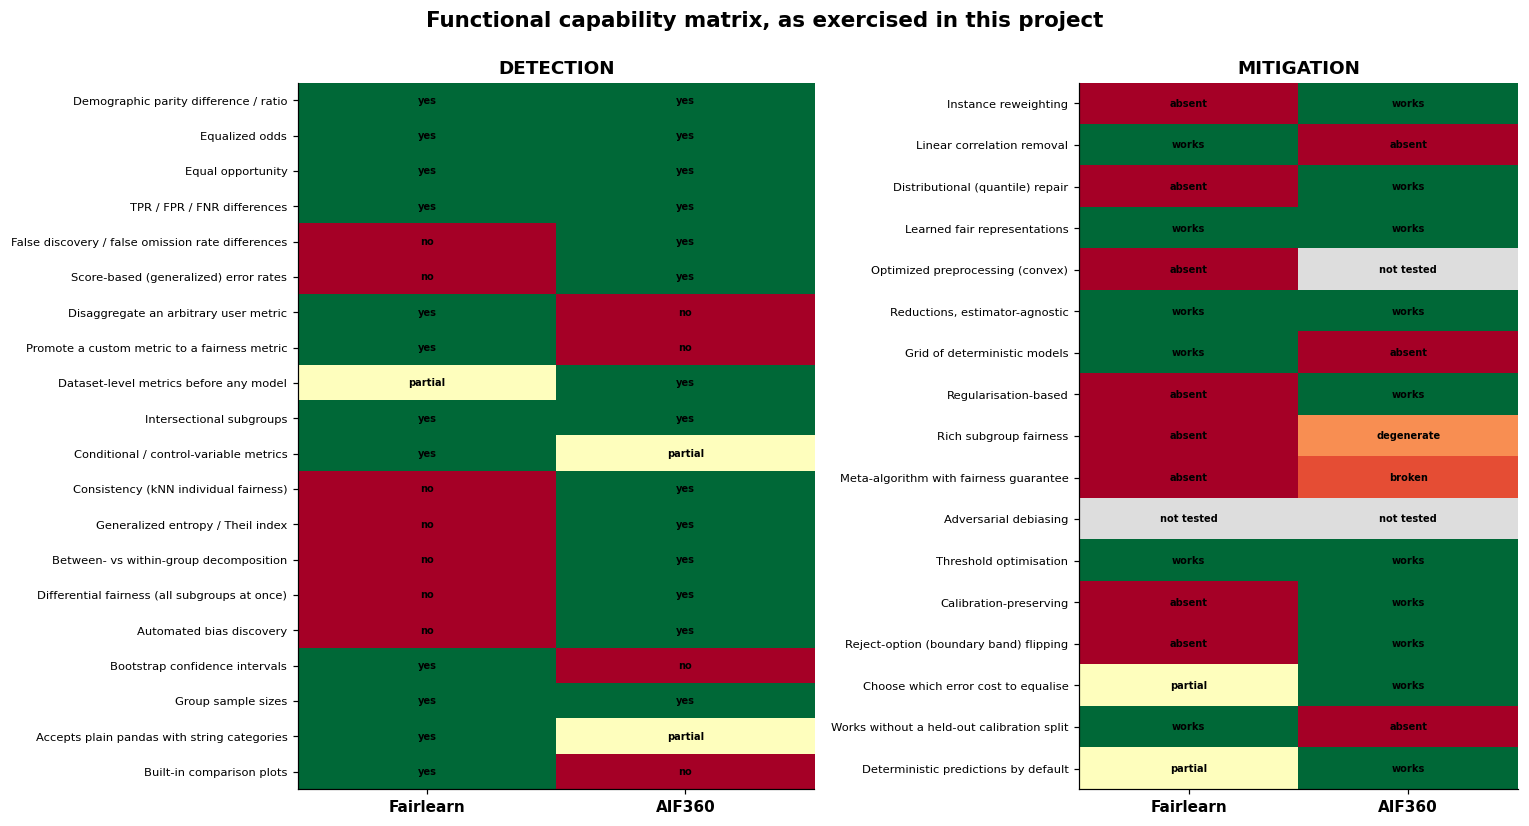

In [9]:
# --- Figure 1: capability matrix as a heatmap -----------------------------
fig, axes = plt.subplots(
    1, 2, figsize=(14, 7.5),
    gridspec_kw={"width_ratios": [len(detection_matrix), len(mitigation_matrix)]},
)

STATUS_VALUE = {"yes": 1.0, "works": 1.0, "partial": 0.5,
                "no": 0.0, "absent": 0.0, "broken": 0.15,
                "degenerate": 0.25, "not tested": np.nan}

for ax, matrix, label_column, title in [
    (axes[0], detection_matrix, "capability", "DETECTION"),
    (axes[1], mitigation_matrix, "capability", "MITIGATION"),
]:
    grid = matrix[["fairlearn", "aif360"]].apply(lambda col: col.map(STATUS_VALUE))
    masked = np.ma.masked_invalid(grid.values.astype(float))
    cmap = plt.cm.RdYlGn.copy()
    cmap.set_bad("#DDDDDD")
    ax.imshow(masked, cmap=cmap, vmin=0, vmax=1, aspect="auto")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Fairlearn", "AIF360"], fontsize=10, fontweight="bold")
    ax.set_yticks(range(len(matrix)))
    ax.set_yticklabels(matrix[label_column], fontsize=7.5)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.grid(False)
    for i in range(len(matrix)):
        for j, library in enumerate(["fairlearn", "aif360"]):
            ax.text(j, i, matrix.iloc[i][library], ha="center", va="center",
                    fontsize=6.5, fontweight="bold")

fig.suptitle("Functional capability matrix, as exercised in this project",
             y=0.995, fontsize=14, fontweight="bold")
fig.tight_layout()
common.savefig(fig, COMPARISON_FIGURES, "cmp_fig1_capability_matrix.png")
plt.show()

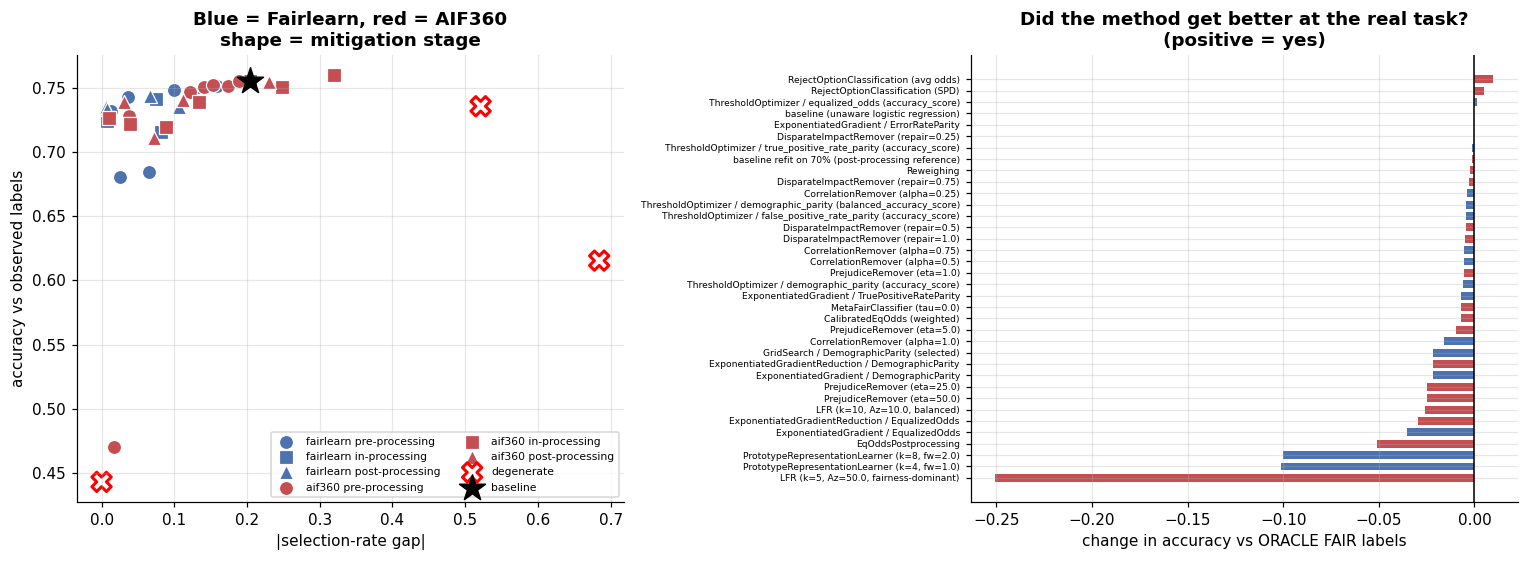

In [10]:
# --- Figure 2: combined tradeoff ------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

STYLE = {("fairlearn", "pre-processing"): ("#4C72B0", "o"),
         ("fairlearn", "in-processing"): ("#4C72B0", "s"),
         ("fairlearn", "post-processing"): ("#4C72B0", "^"),
         ("aif360", "pre-processing"): ("#C44E52", "o"),
         ("aif360", "in-processing"): ("#C44E52", "s"),
         ("aif360", "post-processing"): ("#C44E52", "^")}

usable = combined[~combined.degenerate]
for (library, stage), (colour, marker) in STYLE.items():
    mask = (usable.library == library) & (usable.stage == stage)
    if not mask.any():
        continue
    axes[0].scatter(usable.loc[mask, "DP_difference_signed"].abs(),
                    usable.loc[mask, "accuracy_vs_observed"],
                    c=colour, marker=marker, s=85, edgecolors="white",
                    linewidths=0.8, label=f"{library} {stage}")

axes[0].scatter(combined.loc[combined.degenerate, "DP_difference_signed"].abs(),
                combined.loc[combined.degenerate, "accuracy_vs_observed"],
                facecolors="none", edgecolors="red", marker="X", s=160,
                linewidths=2, label="degenerate")
axes[0].scatter([abs(baseline_reference["DP_difference_signed"])],
                [baseline_reference["accuracy_vs_observed"]],
                c="black", marker="*", s=320, label="baseline", zorder=5)
axes[0].set_xlabel("|selection-rate gap|")
axes[0].set_ylabel("accuracy vs observed labels")
axes[0].set_title("Blue = Fairlearn, red = AIF360\nshape = mitigation stage")
axes[0].legend(fontsize=7, ncol=2)

# Right panel: gain on the oracle fair label.
ranked = usable.sort_values("oracle_accuracy_gain")
colours = ["#4C72B0" if lib == "fairlearn" else "#C44E52" for lib in ranked.library]
axes[1].barh(np.arange(len(ranked)), ranked["oracle_accuracy_gain"], color=colours, height=0.7)
axes[1].axvline(0, c="black", lw=1)
axes[1].set_yticks(np.arange(len(ranked)))
axes[1].set_yticklabels(ranked["method"], fontsize=6)
axes[1].set_xlabel("change in accuracy vs ORACLE FAIR labels")
axes[1].set_title("Did the method get better at the real task?\n(positive = yes)")

fig.tight_layout()
common.savefig(fig, COMPARISON_FIGURES, "cmp_fig2_combined_tradeoff.png")
plt.show()

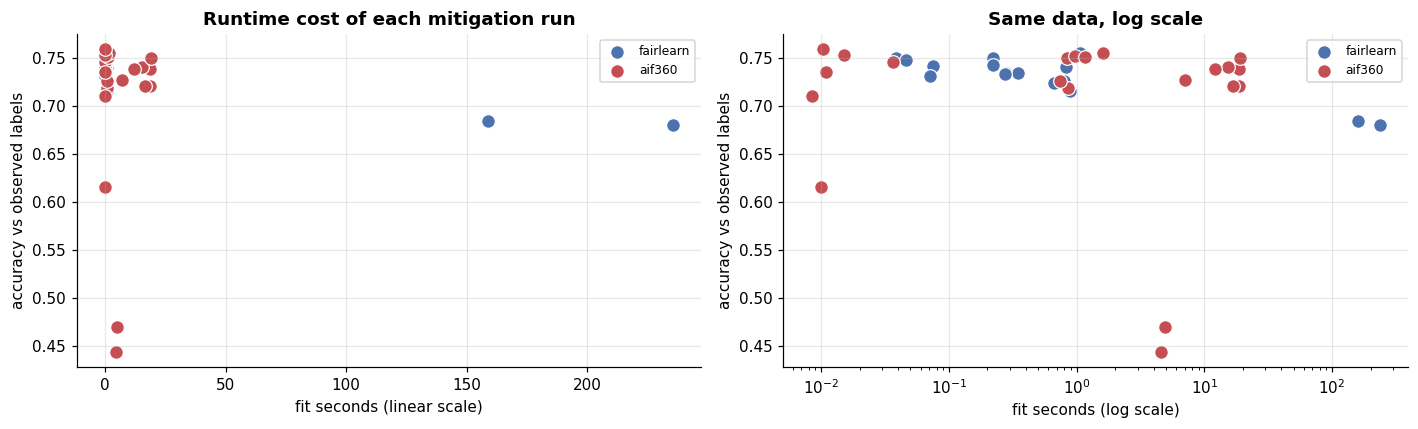

           count    mean    50%      max
library                                 
aif360      21.0   5.866  1.168   18.995
fairlearn   16.0  25.009  0.313  235.486


In [11]:
# --- Figure 3: cost of each library's methods -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

timing = combined.dropna(subset=["fit_seconds"])
timing = timing[timing.fit_seconds > 0]
for ax, scale in [(axes[0], "linear"), (axes[1], "log")]:
    for library, colour in [("fairlearn", "#4C72B0"), ("aif360", "#C44E52")]:
        subset = timing[timing.library == library]
        ax.scatter(subset["fit_seconds"], subset["accuracy_vs_observed"],
                   c=colour, s=80, label=library, edgecolors="white", linewidths=0.8)
    ax.set_xscale(scale)
    ax.set_xlabel(f"fit seconds ({scale} scale)")
    ax.set_ylabel("accuracy vs observed labels")
    ax.legend(fontsize=8)
axes[0].set_title("Runtime cost of each mitigation run")
axes[1].set_title("Same data, log scale")

fig.tight_layout()
common.savefig(fig, COMPARISON_FIGURES, "cmp_fig3_runtime.png")
plt.show()

print(timing.groupby("library")["fit_seconds"].describe().round(3)[
    ["count", "mean", "50%", "max"]
])

## 8. Which library, when

The honest answer is that they are complements more often than substitutes,
and the reason is structural: AIF360's own reduction algorithm *is* Fairlearn.

### Reach for Fairlearn when

* your fairness question is about a **metric you already have** - a business
  KPI, a custom cost function - because `MetricFrame` and `make_derived_metric`
  make any callable a group metric, and AIF360 cannot;
* you need to know whether a disparity is **statistically real**, because only
  Fairlearn bootstraps confidence intervals;
* you want to argue about **conditional** disparities on an arbitrary
  stratifier (`control_features`);
* your model is not a logistic regression - the reductions wrap any estimator,
  whereas most AIF360 in-processors are welded to their own model class;
* you want a **menu of deterministic models** on the frontier (`GridSearch`)
  rather than one randomised ensemble;
* the code has to be maintained by people who have not read the fairness
  literature. The API is smaller, the defaults held up, and everything ran
  first time.

### Reach for AIF360 when

* you need to audit the **data before training** - the whole
  `BinaryLabelDatasetMetric` layer has no Fairlearn counterpart, and it is what
  tells you whether pre-processing is even the right stage to intervene at;
* **individual fairness** matters - `consistency`, Theil, generalized entropy.
  The between/within decomposition in notebook 03a found that group membership
  explains under 1% of individual benefit inequality, a conclusion Fairlearn
  cannot reach;
* you do not know **which subgroup** is harmed - `bias_scan` searches for you,
  subject to the caveat that it trusts the labels you hand it;
* you want **pre-processing options**: `Reweighing` alone justifies the
  dependency, being free, interpretable and estimator-agnostic;
* you need **post-processing control** over which error cost is equalised;
* you are writing for a regulator or a paper and want the widest possible
  metric vocabulary in one place.

### Use both when the work is real

That is the actual recommendation from this project. The two headline findings
each needed a different library:

* Fairlearn found a 0.20 selection-rate gap on `sex` that a model reproduced at
  95% strength **without ever seeing the attribute**, and its bootstrap
  intervals showed the gap was not noise.
* AIF360 then showed that group membership explains under 1% of individual
  benefit inequality, and that `CalibratedEqOdds(fpr)` could "improve fairness"
  while approving **zero** women.

Neither library would have told you both. And the second finding is the one
that would have reached production.

In [12]:
# --- The two headline numbers, restated -----------------------------------
headline = pd.DataFrame([
    {"finding": "Model reproduces the label gap without seeing the attribute",
     "evidence": f"predicted gap {fairlearn_scalars.loc['sex', 'demographic_parity_difference']:.3f} "
                 f"vs {abs(ground_truth['realised_disparities']['sex']['observed_statistical_parity_difference']):.3f} in the labels",
     "library": "Fairlearn (MetricFrame + proxy audit)"},
    {"finding": "Group membership explains <1% of individual benefit inequality",
     "evidence": "between-group GEI / total GEI at alpha=2",
     "library": "AIF360 (entropy decomposition)"},
    {"finding": "A mitigation can equalise its target by approving zero women",
     "evidence": "CalibratedEqOdds(fpr): female selection rate 0.000",
     "library": "AIF360 (post-processing) + panel of metrics"},
    {"finding": "Reductions are the same code in both libraries",
     "evidence": "identical predictions, verified above",
     "library": "both"},
])
headline.to_csv(COMPARISON_RESULTS / "headline_findings.csv", index=False)
display(headline)

print("\nArtefacts written to", COMPARISON_RESULTS)
for path in sorted(COMPARISON_RESULTS.glob("*.csv")):
    print("  ", path.name)

,finding,evidence,library
0,Model reproduces the label gap without seeing the attribute,predicted gap 0.204 vs 0.213 in the labels,Fairlearn (MetricFrame + proxy audit)
1,Group membership explains <1% of individual benefit inequality,between-group GEI / total GEI at alpha=2,AIF360 (entropy decomposition)
2,A mitigation can equalise its target by approving zero women,CalibratedEqOdds(fpr): female selection rate 0.000,AIF360 (post-processing) + panel of metrics
3,Reductions are the same code in both libraries,"identical predictions, verified above",both



Artefacts written to E:\Repo\bias mitigation\comparison\results
   combined_leaderboard.csv
   detection_capability_matrix.csv
   head_to_head.csv
   headline_findings.csv
   mitigation_capability_matrix.csv
